Exploring the dataset

In [19]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import xgboost as xgb
import sklearn
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import make_scorer, balanced_accuracy_score
import numpy as np

In [7]:
# simplified working path (notebook runs from `notebooks/`)
data_path = Path('..') / 'data' / 'BTCUSDT' / 'processed' / 'dataset_candle.parquet'
data_combined_path = Path('..') / 'data' / 'BTCUSDT' / 'processed' / 'dataset_combined.parquet'
data_orderbook_path = Path('..') / 'data' / 'BTCUSDT' / 'processed' / 'dataset_orderbook.parquet'
orderbook_features_path = Path('..') / 'data' / 'BTCUSDT' / 'processed' / 'orderbook_features.parquet'

print('reading', data_path.resolve())
print('reading', data_combined_path.resolve())
print('reading', data_orderbook_path.resolve())
print('reading', orderbook_features_path.resolve())

data = pd.read_parquet(data_path)
data_combined = pd.read_parquet(data_combined_path)
data_orderbook = pd.read_parquet(data_orderbook_path)
orderbook_features = pd.read_parquet(orderbook_features_path)

reading /Users/willemvandesanden/ESL/esl/data/BTCUSDT/processed/dataset_candle.parquet
reading /Users/willemvandesanden/ESL/esl/data/BTCUSDT/processed/dataset_combined.parquet
reading /Users/willemvandesanden/ESL/esl/data/BTCUSDT/processed/dataset_orderbook.parquet
reading /Users/willemvandesanden/ESL/esl/data/BTCUSDT/processed/orderbook_features.parquet


Exploration candle data

Shape: (10080, 13)

Columns:
Index(['open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'num_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'return', 'target'],
      dtype='object')

Head:
                         open      high       low     close     volume  \
2025-12-01 00:01:00  90408.34  90408.34  90300.00  90300.01    9.99673   
2025-12-01 00:02:00  90300.01  90340.25  90278.33  90305.55   31.79438   
2025-12-01 00:03:00  90305.55  90305.55  90194.27  90194.27   57.04552   
2025-12-01 00:04:00  90194.28  90194.28  89510.00  89816.17  503.41775   
2025-12-01 00:05:00  89816.18  89831.89  89522.84  89596.94   76.81928   

                        close_time quote_asset_volume  num_trades  \
2025-12-01 00:01:00  1764547319999    903320.73783330        3915   
2025-12-01 00:02:00  1764547379999   2871422.46471110        4932   
2025-12-01 00:03:00  1764547439999   5146909.31538580        6428   
2025-12-01 00:04:00  1764547499999  4521

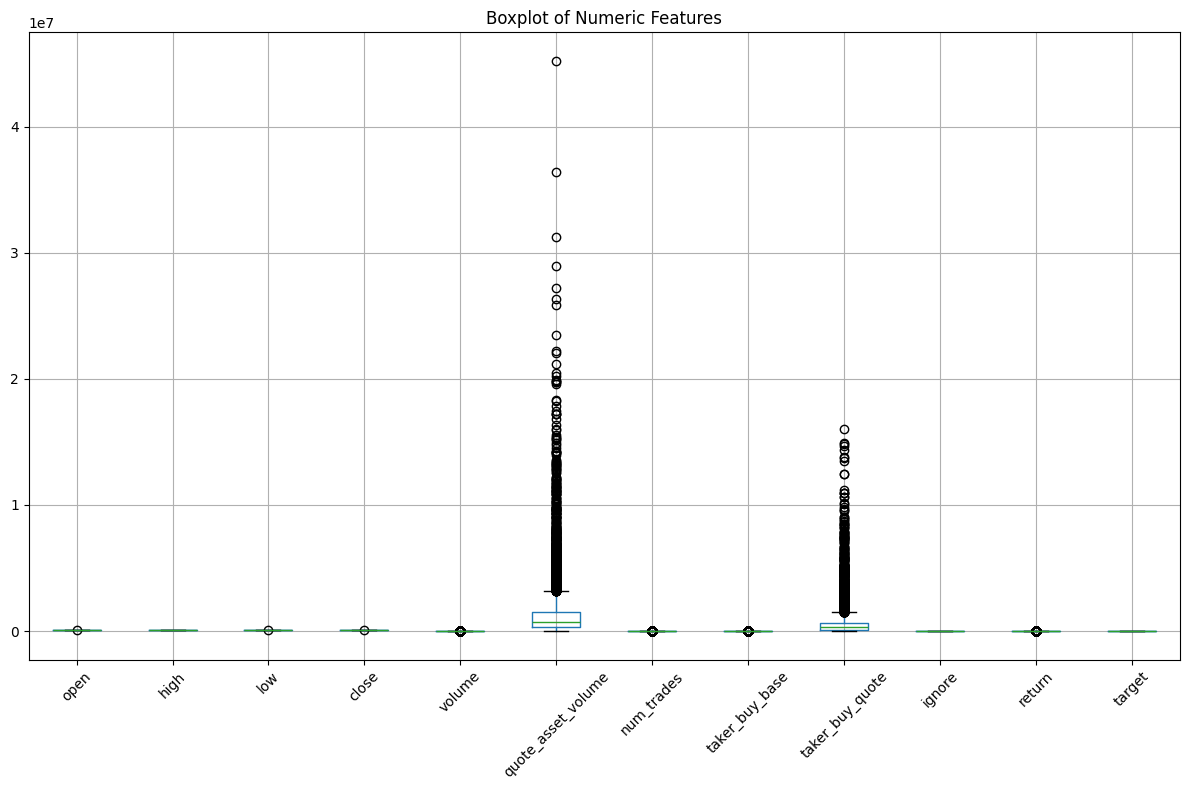

In [ ]:
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nHead:")
print(data.head())

print("\nMissing values per column:")
print(data.isna().sum())

print("\nNumeric summary:")
print(data.describe())

print("\nCategorical summary:")
print(data.describe(include="object"))

# Change Categorical data to numeric
obj_cols = ["quote_asset_volume", "taker_buy_base", "taker_buy_quote", "ignore"]
data[obj_cols] = data[obj_cols].apply(pd.to_numeric, errors="coerce")
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Remove close_time from numeric columns for plotting
numeric_cols.remove('close_time')

print("\nInfo:")
print(data.info())
plt.figure(figsize=(12, 8))
data[numeric_cols].boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Exploration orderbook data

Shape: (10080, 7)

Columns:
Index(['bid_ask_spread', 'midprice', 'bid_depth', 'ask_depth',
       'orderbook_imbalance', 'weighted_imbalance', 'target'],
      dtype='object')

Head:
                     bid_ask_spread      midprice  bid_depth  ask_depth  \
2025-12-01 00:01:00        2.757000  90305.466833   2.545783   6.513597   
2025-12-01 00:02:00        3.860833  90274.919917   3.089707   5.574597   
2025-12-01 00:03:00        2.417500  90182.653417   3.302455   4.890423   
2025-12-01 00:04:00       -6.448500  89799.948917   2.613020   3.611227   
2025-12-01 00:05:00       -3.686333  89596.676667   2.757617   4.025313   

                     orderbook_imbalance  weighted_imbalance  target  
2025-12-01 00:01:00            -0.257210           -0.259774       0  
2025-12-01 00:02:00            -0.154786           -0.114115      -1  
2025-12-01 00:03:00            -0.166560           -0.122696      -1  
2025-12-01 00:04:00            -0.032481           -0.014712      -1  
2025-12-01 

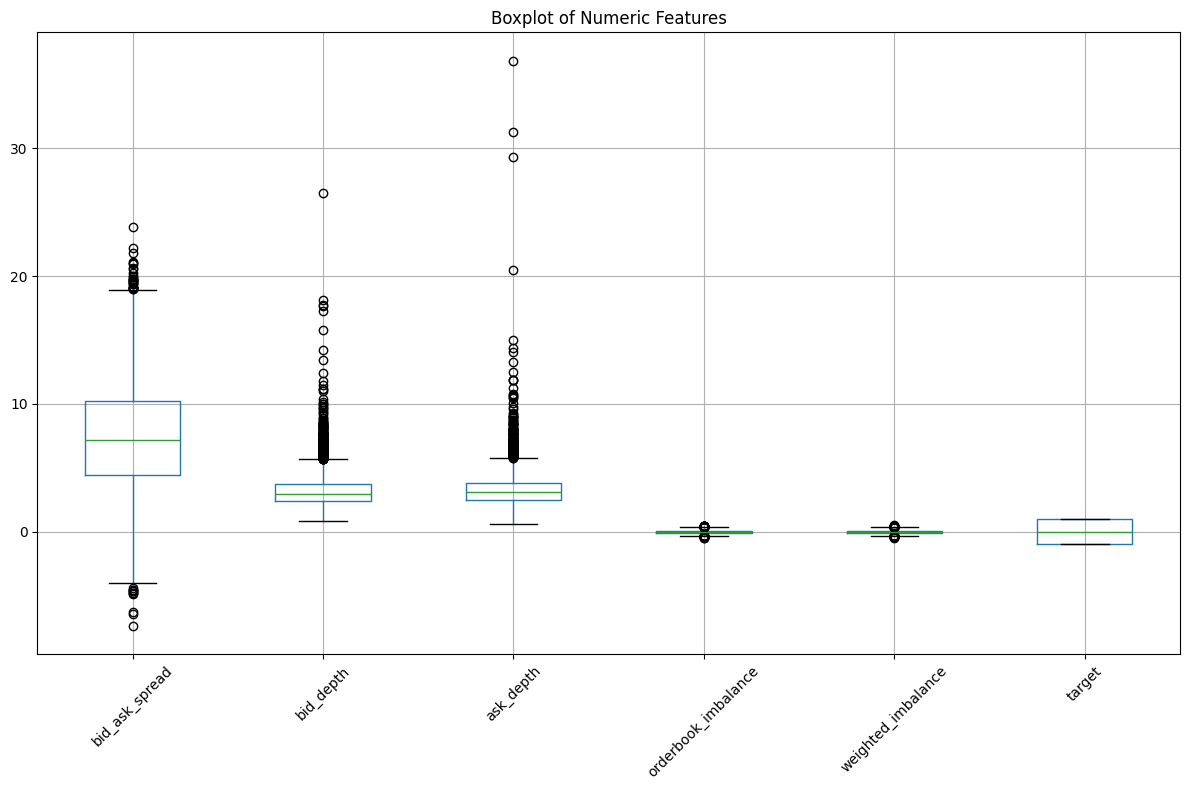

In [17]:
print("Shape:", data_orderbook.shape)
print("\nColumns:")
print(data_orderbook.columns)

print("\nHead:")
print(data_orderbook.head())

print("\nMissing values per column:")
print(data_orderbook.isna().sum())

print("\nNumeric summary:")
print(data_orderbook.describe())
data_orderbook = data_orderbook.drop(columns=["midprice"])
numeric_cols = data_orderbook.select_dtypes(include=[np.number]).columns.tolist()

print("\nInfo:")
print(data_orderbook.info())
plt.figure(figsize=(12, 8))
data_orderbook[numeric_cols].boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

XGBoost on candle data

In [20]:
data = data.drop(columns=["ignore", "close_time"], errors="ignore")

X = data.drop(columns=['target'])
y_raw = data['target']                                                              
y= y_raw.map({-1: 0, 0: 1, 1: 2}).astype(int)  # Map -1 to 0, 0 to 1, and 1 to 2 for multiclass classification

gap = 5  # minutes
n = len(X)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val,   y_val   = X.iloc[train_end+gap:val_end], y.iloc[train_end+gap:val_end]
X_test,  y_test  = X.iloc[val_end+gap:], y.iloc[val_end+gap:]

class_counts = y_train.value_counts().sort_index()
class_weights = (class_counts.sum() / class_counts).to_dict()
w_train = y_train.map(class_weights).astype(float)


# Combine train + val into one "tuning" dataset
X_tune = np.vstack([X_train.values, X_val.values])
y_tune = np.concatenate([y_train.values, y_val.values])

# sample weights for val too (use train-derived weights or recompute on train+val)
class_counts = y_train.value_counts().sort_index()
class_weights = (class_counts.sum() / class_counts).to_dict()
w_val = y_val.map(class_weights).astype(float)
w_tune = np.concatenate([w_train.values, w_val.values])

# tell sklearn: -1 means "always train", 0 means "validation fold"
test_fold = np.r_[np.full(len(X_train), -1), np.zeros(len(X_val))]
ps = PredefinedSplit(test_fold)

base = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss",
)

scorer = make_scorer(balanced_accuracy_score)

param_grid = {
    "max_depth": [2, 3, 4],
    "min_child_weight": [5, 10, 20],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
    "gamma": [0.0, 0.1, 0.5],
    "learning_rate": [0.02, 0.05],
    "n_estimators": [400, 800, 1200],
}

grid = GridSearchCV(
    base, param_grid=param_grid, scoring=scorer, cv=ps,
    n_jobs=-1, verbose=2, refit=True
)

grid.fit(X_tune, y_tune, sample_weight=w_tune)

print("Best val score:", grid.best_score_)
print("Best params:", grid.best_params_)

best = grid.best_estimator_
pred = best.predict(X_test)

print("Balanced accuracy:", balanced_accuracy_score(y_test, pred))

# clf = xgb.XGBClassifier(
#     objective="multi:softprob",
#     num_class=3,
#     tree_method="hist",
#     n_estimators=3000,
#     learning_rate=0.03,
#     max_depth=4,
#     min_child_weight=5,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_lambda=1.0,
#     reg_alpha=0.0,
#     gamma=0.0,
#     random_state=42,
# )

# clf.fit(
#     X_train, y_train,
#     sample_weight=w_train,
#     eval_set=[(X_val, y_val)],
#     verbose=50,
#     # early_stopping_rounds=100
# )

# pred = clf.predict(X_test)

# print("Balanced accuracy:", balanced_accuracy_score(y_test, pred))
# print(confusion_matrix(y_test, pred))
# print(classification_report(y_test, pred, digits=4, target_names=["down", "flat", "up"]))


Fitting 1 folds for each of 4374 candidates, totalling 4374 fits
[CV] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.02, max_depth=2, min_child_weight=5, n_estimators=400, reg_lambda=5.0, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.02, max_depth=2, min_child_weight=5, n_estimators=400, reg_lambda=10.0, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.02, max_depth=2, min_child_weight=5, n_estimators=400, reg_lambda=1.0, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.02, max_depth=2, min_child_weight=5, n_estimators=400, reg_lambda=10.0, subsample=0.85; total time=   0.4s
[CV] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.02, max_depth=2, min_child_weight=5, n_estimators=400, reg_lambda=1.0, subsample=0.85; total time=   0.5s
[CV] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.02, max_depth=2, min_child_weight=5, n_estimators=400, reg

/Users/willemvandesanden/ESL/esl/.venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.05, max_depth=2, min_child_weight=10, n_estimators=1200, reg_lambda=10.0, subsample=0.7; total time=   1.5s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.05, max_depth=2, min_child_weight=10, n_estimators=1200, reg_lambda=10.0, subsample=1.0; total time=   1.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.05, max_depth=2, min_child_weight=10, n_estimators=1200, reg_lambda=10.0, subsample=0.85; total time=   1.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.05, max_depth=2, min_child_weight=20, n_estimators=800, reg_lambda=1.0, subsample=1.0; total time=   0.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.05, max_depth=2, min_child_weight=20, n_estimators=800, reg_lambda=1.0, subsample=0.85; total time=   0.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.05, max_depth=2, min_child_weight=20, n_estimators=800, reg_lambda=1.0, subsample=0.7; total time=   1.1s
[CV] END

XGBoost on orderbook data